In [1]:
import gtsam
import numpy as np
import matplotlib.pyplot as plt
from gtbook.display import show
from gtsam.symbol_shorthand import X, L
from gtsam import symbolChr, symbolIndex
import gtsam.utils.plot as gtsam_plot
from utilities.utils import kstr
from data.data_generator_linear import SimulationConfig, RobotSimulatorR2, build_linear_factor_graph

### Create factor graph

In [ ]:
# Create simulation configuration
config = SimulationConfig(
    poses=[
        np.array([0.0, 0.0]),  # X1
        np.array([2.0, 0.0]),  # X2
        np.array([4.0, 0.0])   # X3
    ],
    landmarks=[
        np.array([2.0, 2.0]),  # L1
        np.array([4.0, 2.0])   # L2
    ],
    observations={ # could potentially use max distance to determine this
        0: [0],     # X1 sees L1
        1: [0],     # X2 sees L1
        2: [1]      # X3 sees L2
    },
    prior_noise_sim=np.array([0, 0]),
    odometry_noise_sim=np.array([0.1, 0.1]),
    measurement_noise_sim=np.array([0.1, 0.1])
)

simulator = RobotSimulatorR2(config)
sim_data = simulator.simulate()

gfg = build_linear_factor_graph(
    sim_data,
    prior_noise_fg=np.array([0.1, 0.1]), # use true noise for now
    odometry_noise_fg=np.array([0.2, 0.2]),  
    measurement_noise_fg=np.array([0.05, 0.05])
)

pose_vars = [X(i+1) for i in range(len(sim_data['ground_truth']['poses']))]
landmark_vars = [L(i+1) for i in range(len(sim_data['ground_truth']['landmarks']))]
all_vars = pose_vars + landmark_vars

### Optimization

solution = VectorValues: 5 elements
  l1:  2.1356 2.03151
  l2: 4.11093 2.16455
  x1: -2.27374e-15 -1.13687e-15
  x2:  2.02995 0.172442
  x3:   4.14181 0.0232172
 with error 0.386440725055189
solution_dense = VectorValues: 5 elements
  l1:  2.1356 2.03151
  l2: 4.11093 2.16455
  x1: -3.74431e-15 -3.84285e-15
  x2:  2.02995 0.172442
  x3:   4.14181 0.0232172
 with error 0.38644072505519006


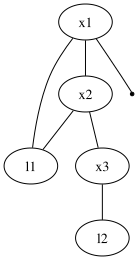

In [ ]:
solution = gfg.optimize()
print(f"solution = {solution} with error {gfg.error(solution)}")

solution_dense = gfg.optimizeDensely()
print(f"solution_dense = {solution_dense} with error {gfg.error(solution_dense)}")
show(gfg, binary_edges=True)

### Covariances

The $d$ below is the "square root information vector", as the Bayes net defines the following quadratic, and corresponding Gaussian density, in this case in $\mathbb{R}^6$:

$$
E_{gbn}(x; R, d) \doteq \frac{1}{2} \|Rx - d\|^2
$$

$$
\mathcal{N}_{gbn}(x; R, d) \sim k \exp \{- \frac{1}{2} \|Rx - d\|^2\}
$$

In [85]:
# Convert to Gaussian Bayes Net
gbn = gfg.eliminateSequential()

R, d = gbn.matrix() # Suquare root information matrix (R) and vector (d)
I_from_R = R.T @ R
P_from_R = np.linalg.inv(I_from_R) 

#### Covariance Computation Methods in GTSAM

There are two common ways to obtain covariance matrices from a factor graph:

1. **From the Hessian (Information Form)**  
   - The factor graph can be expressed in canonical Gaussian form  
     $
     E(x) = \tfrac{1}{2} x^\top \Lambda x - x^\top \eta + \text{const},
     $  
     where $\Lambda = P^{-1}$ is the **information matrix**.  
   - Calling `gfg.hessian()` constructs this global information matrix \(\Lambda\).  
   - Inverting it yields the full covariance:  
     $
     P_{\text{information}} = \Lambda^{-1}.
     $  
   - Marginal covariances of subsets of variables can then be obtained by slicing the corresponding blocks of $P_{\text{information}}$.  
   - **Advantage:** straightforward, gives full covariance.  
   - **Disadvantage:** requires inverting the entire information matrix (expensive for large problems).  

2. **From Marginalization (Elimination-Based)**  
   - The `Marginals` class computes covariances by **eliminating variables** in the factor graph (e.g., via Cholesky factorization).  
   - This allows extracting only the covariance for a subset of variables without forming the entire $P$.  
   - Calling `marginals.marginalCovariance(key)` gives the covariance for one variable.  
   - Calling `marginals.jointMarginalCovariance(keys)` gives the joint covariance matrix for a set of variables.  
   - **Advantage:** efficient for subsets; avoids computing the full inverse.  
   - **Disadvantage:** requires repeated queries if many different marginals are needed.  

---

**Key Point:** Both methods give the *same result mathematically*. The difference is purely in **how the computation is carried out**:  
- **Hessian inversion:** global, dense, expensive.  
- **Marginals API:** local, on-demand, efficient.  


In [ ]:
# Marginals object
marginals = gtsam.Marginals(gfg, solution)
joint_cov_marginals = marginals.jointMarginalCovariance(all_vars)
P_from_marginals = joint_cov_marginals.fullMatrix()

# Compute global covariance from Hessian
I_from_hessian, _ = gfg.hessian()
P_from_hessian = np.linalg.inv(I_from_hessian)


gfg.at(5).keys()


[8646911284551352323, 7782220156096217090]

### Comparing covariances

In [87]:
np.set_printoptions(precision=6, suppress=False)

# Compare individual pose covariances
for i, key in enumerate(all_vars, start=1):
    cov_from_joint = joint_cov_marginals.at(key, key)
    cov_from_marg = marginals.marginalCovariance(key)

    print(f"{kstr(key)}:")
    # print("From full joint cov matrix:\n", cov_from_joint)
    print("From marginals:\n", cov_from_marg)
    print("Equal? ->", np.allclose(cov_from_joint, cov_from_marg, atol=1e-10))
    print("-"*50)

# Compare joint covariance (all poses together)
joint_cov = marginals.jointMarginalCovariance(all_vars).fullMatrix()
print("Joint covariance (marginals) vs. full inverse match? ->",
      np.allclose(P_from_marginals, P_from_hessian, atol=1e-8))


X1:
From marginals:
 [[0.01 0.  ]
 [0.   0.01]]
Equal? -> True
--------------------------------------------------
X2:
From marginals:
 [[0.014444 0.      ]
 [0.       0.014444]]
Equal? -> True
--------------------------------------------------
X3:
From marginals:
 [[0.054444 0.      ]
 [0.       0.054444]]
Equal? -> True
--------------------------------------------------
L1:
From marginals:
 [[0.012361 0.      ]
 [0.       0.012361]]
Equal? -> True
--------------------------------------------------
L2:
From marginals:
 [[0.056944 0.      ]
 [0.       0.056944]]
Equal? -> True
--------------------------------------------------
Joint covariance (marginals) vs. full inverse match? -> True


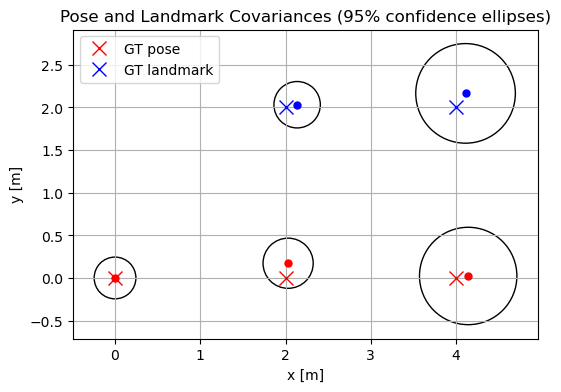

xlim: (np.float64(-0.4926609851694043), np.float64(4.960837661059243)), ylim: (np.float64(-0.7127529241154115), np.float64(2.9134897907333293))


In [88]:
fig, ax = plt.subplots(figsize=(6, 6))

for i, key in enumerate(all_vars, start=1):
    mean = solution.at(key)
    cov = marginals.marginalCovariance(key)

    if kstr(key)[0] == 'X':
        gtsam_plot.plot_point2_on_axes(ax, point=mean, linespec='r', P=cov)
    elif kstr(key)[0] == 'L':
        gtsam_plot.plot_point2_on_axes(ax, point=mean, linespec='b', P=cov)

for i, pose in enumerate(sim_data['ground_truth']['poses']):
    ax.plot(pose[0], pose[1], 'rx', markersize=10, label='GT pose' if i == 0 else "")
for i, landmark in enumerate(sim_data['ground_truth']['landmarks']):
    ax.plot(landmark[0], landmark[1], 'bx', markersize=10, label='GT landmark' if i == 0 else "")

ax.set_title("Pose and Landmark Covariances (95% confidence ellipses)")
ax.grid(True)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect('equal', 'box')
ax.legend()
plt.show()

xlim, ylim = ax.get_xlim(), ax.get_ylim()
print(f"xlim: {xlim}, ylim: {ylim}")

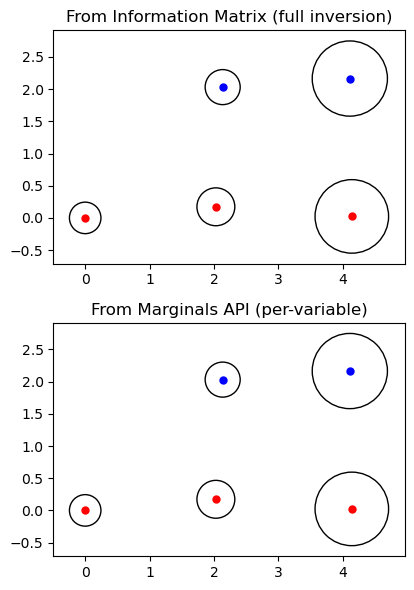

In [89]:
fig, axs = plt.subplots(2, 1, figsize=(22, 6))

for ax, title, cov_source in zip(axs,
    ["From Information Matrix (full inversion)", "From Marginals API (per-variable)"],
    ["joint", "marginals"]
):

    ax.set_aspect('equal')
    ax.set_title(title)

    for i, var in enumerate(all_vars, start=1):
        mean = solution.at(var)

        if cov_source == "joint":
            cov = joint_cov_marginals.at(var, var)
        elif cov_source == "marginals":
            cov = marginals.marginalCovariance(var)

        if kstr(var)[0] == 'X':
            gtsam_plot.plot_point2_on_axes(ax, point=mean, linespec='r', P=cov)
        elif kstr(var)[0] == 'L':
            gtsam_plot.plot_point2_on_axes(ax, point=mean, linespec='b', P=cov)

plt.tight_layout()
plt.show()